# Abstract Data Quality Check
Investigates `raw.raw_paper_searches.abstract` for nulls, length anomalies, encoding issues, placeholder text, duplicates, and non-English content.

In [3]:
import re
import sys
import unicodedata
from pathlib import Path

sys.path.insert(0, str(Path('..') / 'src'))

import matplotlib.pyplot as plt
import pandas as pd
from literature_ai.core.db import load_table

## 1. Load data

In [4]:
df = load_table('raw.raw_paper_searches')
print(f"Total rows: {len(df):,}")
df[['paperId', 'title', 'abstract', 'year', 'venue']].head(3)

Total rows: 4,702


,paperId,title,abstract,year,venue
0,2c03df8b48bf3fa39054345bafabfeff15bfd11d,Deep Residual Learning for Image Recognition,Deeper neural networks are more difficult to t...,2015.0,Computer Vision and Pattern Recognition
1,dc32a984b651256a8ec282be52310e6bd33d9815,Highly accurate protein structure prediction w...,"Proteins are essential to life, and understand...",2021.0,Nature
2,5582bebed97947a41e3ddd9bd1f284b73f1648c2,Grad-CAM: Visual Explanations from Deep Networ...,We propose a technique for producing ‘visual e...,2016.0,International Journal of Computer Vision


## 2. Null / missing abstracts

In [5]:
n_null = df['abstract'].isna().sum()
n_empty = (df['abstract'].fillna('').str.strip() == '').sum()
n_total = len(df)

print(f"NULL abstracts   : {n_null:,} ({n_null/n_total:.1%})")
print(f"Empty/whitespace : {n_empty:,} ({n_empty/n_total:.1%})")
print(f"Has content      : {n_total - n_empty:,} ({(n_total - n_empty)/n_total:.1%})")

NULL abstracts   : 218 (4.6%)
Empty/whitespace : 218 (4.6%)
Has content      : 4,484 (95.4%)


## 3. Abstract length distribution

Character length statistics (non-empty only):


,chars
count,4484.000000
mean,1437.059991
std,566.802441
min,111.000000
1%,581.490000
5%,784.150000
25%,1104.000000
50%,1359.000000
75%,1657.000000
95%,2290.850000


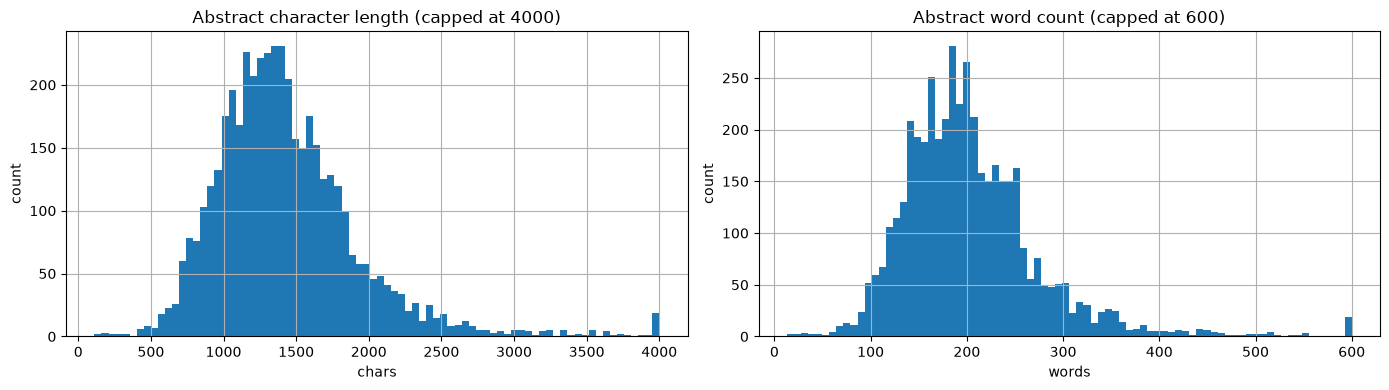

In [6]:
df['abstract_len'] = df['abstract'].fillna('').str.len()
df['abstract_words'] = df['abstract'].fillna('').str.split().str.len()

print("Character length statistics (non-empty only):")
non_empty = df[df['abstract_len'] > 0]['abstract_len']
display(non_empty.describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).rename('chars').to_frame())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
non_empty.clip(upper=4000).hist(bins=80, ax=axes[0])
axes[0].set(title='Abstract character length (capped at 4000)', xlabel='chars', ylabel='count')

df[df['abstract_words'] > 0]['abstract_words'].clip(upper=600).hist(bins=80, ax=axes[1])
axes[1].set(title='Abstract word count (capped at 600)', xlabel='words', ylabel='count')
plt.tight_layout()
plt.show()

## 4. Very short abstracts

In [7]:
SHORT_CHAR_THRESHOLD = 50
SHORT_WORD_THRESHOLD = 10

short = df[(df['abstract_len'] > 0) & (df['abstract_len'] < SHORT_CHAR_THRESHOLD)].copy()
print(f"Abstracts under {SHORT_CHAR_THRESHOLD} chars: {len(short):,}")
display(short[['paperId', 'title', 'abstract', 'year']].head(20))

short_words = df[(df['abstract_words'] > 0) & (df['abstract_words'] < SHORT_WORD_THRESHOLD)].copy()
print(f"\nAbstracts under {SHORT_WORD_THRESHOLD} words: {len(short_words):,}")
display(short_words[['paperId', 'title', 'abstract', 'year']].head(20))

Abstracts under 50 chars: 0


,paperId,title,abstract,year



Abstracts under 10 words: 0


,paperId,title,abstract,year


## 5. Very long abstracts

In [8]:
LONG_CHAR_THRESHOLD = 5000

long_abs = df[df['abstract_len'] > LONG_CHAR_THRESHOLD].copy()
print(f"Abstracts over {LONG_CHAR_THRESHOLD:,} chars: {len(long_abs):,}")
display(long_abs[['paperId', 'title', 'abstract_len', 'abstract_words', 'year']].head(20))

print("\nTop 5 longest abstracts:")
display(df.nlargest(5, 'abstract_len')[['paperId', 'title', 'abstract_len', 'year']])

Abstracts over 5,000 chars: 14


,paperId,title,abstract_len,abstract_words,year
253,a82137965925d7712dfb720e1f2ad39251d799eb,Accurate proteome-wide missense variant effect...,5793,796,2023.0
452,d2a595c5efb4b26245c4353d5d85cbe6c7ecac0f,Machine learning for data-driven discovery in ...,6118,881,2019.0
609,2eb1ed9d4baf548391d8220c0a8a3d0be79845ed,Boltzmann generators: Sampling equilibrium sta...,6284,885,2019.0
2427,f7fea1eb9bf84d0689d88c3a3258e77b24210a4e,With an eye to AI and autonomous diagnosis,6512,986,2018.0
2822,eff1a13998746bc034afd1f676d444b0cb203a77,Quantum internet: A vision for the road ahead,5795,859,2018.0
2979,82a5a84528a7ca0409f75e2211a3b33a217e9bac,Ensuring Fairness in Machine Learning to Advan...,10000,1495,2018.0
3039,d9b3234e87a16487d18d6cda7fdf62096ef86935,"Materials that couple sensing, actuation, comp...",6079,851,2015.0
3136,52b5a3baf789b6347e8e95d43318197e60780842,Using satellite imagery to understand and prom...,6233,850,2019.0
3670,9b3b56ba47277eeae136f9c369e90b91f4b39fc2,ESHRE guideline: endometriosis,7378,1030,2022.0
3671,2a5bed915f10e2467397f55d0fd0c7cbb51696e6,PROBAST: A Tool to Assess Risk of Bias and App...,10000,1448,2019.0



Top 5 longest abstracts:


,paperId,title,abstract_len,year
2979,82a5a84528a7ca0409f75e2211a3b33a217e9bac,Ensuring Fairness in Machine Learning to Advan...,10000,2018.0
3671,2a5bed915f10e2467397f55d0fd0c7cbb51696e6,PROBAST: A Tool to Assess Risk of Bias and App...,10000,2019.0
3670,9b3b56ba47277eeae136f9c369e90b91f4b39fc2,ESHRE guideline: endometriosis,7378,2022.0
3685,dab85d00ab9d6df536d31df970510ceaed99b7c3,Viral epitope profiling of COVID-19 patients r...,6853,2020.0
2427,f7fea1eb9bf84d0689d88c3a3258e77b24210a4e,With an eye to AI and autonomous diagnosis,6512,2018.0


## 6. Placeholder / boilerplate patterns

In [10]:
PLACEHOLDER_PATTERNS = [
    r'^no abstract',
    r'^abstract not available',
    r'^not available',
    r'^n/?a\.?$',
    r'^abstract\s*:\s*$',
    r'^abstract$',
    r'^summary$',
    r'^\[no abstract\]',
    r'^redacted',
    r'^see (the )?abstract',
]

combined = '|'.join(PLACEHOLDER_PATTERNS)
placeholder_mask = df['abstract'].fillna('').str.match(combined, case=False)
placeholders = df[placeholder_mask]
print(f"Potential placeholder abstracts: {len(placeholders):,}")
if len(placeholders):
    display(placeholders[['paperId', 'title', 'abstract']].head(30))

Potential placeholder abstracts: 0


## 7. Duplicate abstracts

In [11]:
df['abstract_norm'] = df['abstract'].fillna('').str.lower().str.strip()

dup_mask = df['abstract_norm'].ne('') & df['abstract_norm'].duplicated(keep=False)
dups = df[dup_mask].sort_values('abstract_norm')
n_dup_groups = dups['abstract_norm'].nunique()

print(f"Rows sharing an identical abstract: {len(dups):,} across {n_dup_groups:,} distinct texts")

if n_dup_groups:
    print("\nLargest duplicate groups:")
    top_dups = (
        dups.groupby('abstract_norm')
        .agg(count=('paperId', 'count'), paper_ids=('paperId', list))
        .sort_values('count', ascending=False)
        .head(10)
    )
    top_dups['abstract_preview'] = top_dups.index.str[:120]
    display(top_dups[['count', 'abstract_preview', 'paper_ids']])

Rows sharing an identical abstract: 0 across 0 distinct texts


## 8. Encoding / character issues

In [12]:
def has_control_chars(text: str) -> bool:
    return bool(re.search(r'[\x00-\x08\x0b\x0c\x0e-\x1f\x7f]', text))

def has_replacement_char(text: str) -> bool:
    return '\ufffd' in text

abstracts = df['abstract'].fillna('')

ctrl_mask = abstracts.apply(has_control_chars)
repl_mask = abstracts.apply(has_replacement_char)

print(f"Control characters (non-printable) : {ctrl_mask.sum():,}")
print(f"Unicode replacement char (\\ufffd)   : {repl_mask.sum():,}")

if ctrl_mask.sum():
    print("\nSample — control chars:")
    display(df[ctrl_mask][['paperId', 'title', 'abstract']].head(5))

if repl_mask.sum():
    print("\nSample — replacement char:")
    display(df[repl_mask][['paperId', 'title', 'abstract']].head(5))

Control characters (non-printable) : 0
Unicode replacement char (\ufffd)   : 0


## 9. Non-English abstracts (heuristic)

In [13]:
NON_LATIN_THRESHOLD = 0.10

def non_latin_ratio(text: str) -> float:
    if not text:
        return 0.0
    non_latin = sum(
        1 for c in text
        if unicodedata.category(c).startswith('L') and ord(c) > 591
    )
    return non_latin / max(len(text), 1)

df['non_latin_ratio'] = df['abstract'].fillna('').apply(non_latin_ratio)
likely_non_english = df[df['non_latin_ratio'] > NON_LATIN_THRESHOLD]

print(f"Likely non-English abstracts: {len(likely_non_english):,} ({len(likely_non_english)/n_total:.1%})")
if len(likely_non_english):
    display(likely_non_english[['paperId', 'title', 'abstract', 'non_latin_ratio']].head(20))

Likely non-English abstracts: 0 (0.0%)


## 10. HTML / LaTeX artefacts

In [15]:
html_mask = df['abstract'].fillna('').str.contains(r'<[a-zA-Z][^>]*>', regex=True)
latex_mask = df['abstract'].fillna('').str.contains(r'\\[a-zA-Z]+\{', regex=True)
html_entity_mask = df['abstract'].fillna('').str.contains(r'&[a-zA-Z]+;|&#\d+;', regex=True)

print(f"HTML tags present      : {html_mask.sum():,}")
print(f"LaTeX commands present : {latex_mask.sum():,}")
print(f"HTML entities present  : {html_entity_mask.sum():,}")

def print_abstracts(label, mask, n=5):
    sample = df[mask].head(n)
    if sample.empty:
        return
    print(f"\nSample — {label}:")
    for _, row in sample.iterrows():
        print(f"\n  [{row['paperId']}] {row['title']}")
        print(f"  {row['abstract']}")

print_abstracts("HTML tags", html_mask)
print_abstracts("HTML entities", html_entity_mask)
print_abstracts("LaTeX", latex_mask)

HTML tags present      : 21
LaTeX commands present : 40
HTML entities present  : 5

Sample — HTML tags:

  [8a68ca7c5ba4d92de3435961f88188d0b769b920] Deep Convolutional Neural Network for Inverse Problems in Imaging
  In this paper, we propose a novel deep convolutional neural network (CNN)-based algorithm for solving ill-posed inverse problems. Regularized iterative algorithms have emerged as the standard approach to ill-posed inverse problems in the past few decades. These methods produce excellent results, but can be challenging to deploy in practice due to factors including the high computational cost of the forward and adjoint operators and the difficulty of hyperparameter selection. The starting point of this paper is the observation that unrolled iterative methods have the form of a CNN (filtering followed by pointwise non-linearity) when the normal operator (<inline-formula> <tex-math notation="LaTeX">$H^{*}H$ </tex-math></inline-formula>, where <inline-formula> <tex-math notat

## 11. Summary

In [ ]:
issues = {
    'NULL abstract': df['abstract'].isna().sum(),
    'Empty / whitespace-only': (df['abstract'].fillna('').str.strip() == '').sum(),
    f'Very short (< {SHORT_CHAR_THRESHOLD} chars)': (df['abstract_len'].between(1, SHORT_CHAR_THRESHOLD - 1)).sum(),
    f'Very long (> {LONG_CHAR_THRESHOLD:,} chars)': (df['abstract_len'] > LONG_CHAR_THRESHOLD).sum(),
    'Placeholder text': placeholder_mask.sum(),
    'Duplicate abstract': dup_mask.sum(),
    'Control characters': ctrl_mask.sum(),
    'Unicode replacement char': repl_mask.sum(),
    f'Likely non-English (non-Latin > {NON_LATIN_THRESHOLD:.0%})': len(likely_non_english),
    'HTML tags': html_mask.sum(),
    'HTML entities': html_entity_mask.sum(),
    'LaTeX commands': latex_mask.sum(),
}

summary = (
    pd.DataFrame.from_dict(issues, orient='index', columns=['count'])
    .assign(pct=lambda d: (d['count'] / n_total * 100).round(2))
)
summary.index.name = 'issue'
display(summary)